In [53]:
!pip install xgboost -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

In [54]:
df = pd.read_csv("/content/sample_data/creditcard.csv")
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (15936, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [55]:
print("Missing Values:\n", df.isnull().sum())

duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

df = df.drop_duplicates()
print("Shape After Cleaning:", df.shape)

Missing Values:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       1
V24       1
V25       1
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64
Duplicate rows: 53
Shape After Cleaning: (15883, 31)


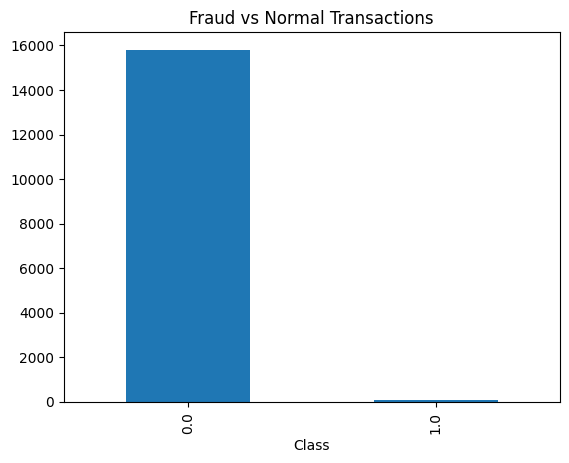

Fraud Percentage: 0.459610904740918


In [56]:
counts = df["Class"].value_counts()

counts.plot(kind="bar", title="Fraud vs Normal Transactions")
plt.show()

print("Fraud Percentage:", counts[1]/len(df)*100)

In [57]:
scaler = StandardScaler()

df["Amount"] = scaler.fit_transform(df[["Amount"]])
df["Time"] = scaler.fit_transform(df[["Time"]])

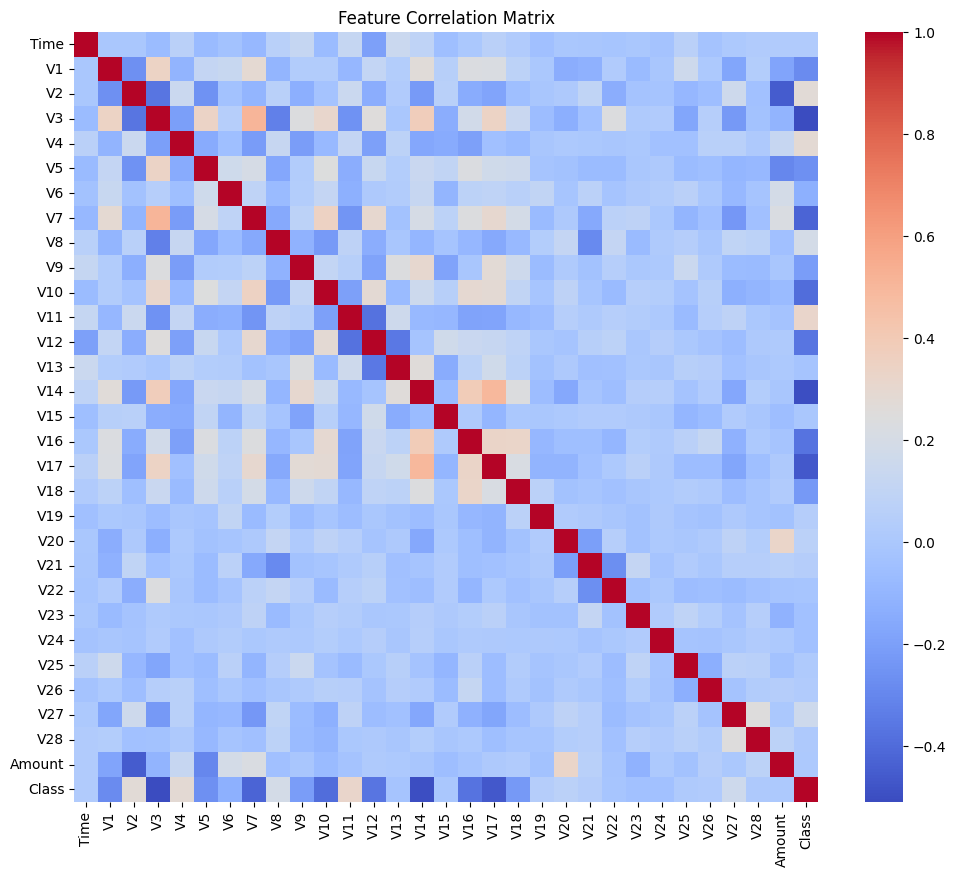

In [58]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

In [59]:
df = df.sort_values("Time").reset_index(drop=True)

In [60]:
X = df.drop("Class", axis=1)
y = df["Class"]
amounts = df["Amount"].copy()

In [61]:
split_index = int(len(df)*0.7)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

amount_test = amounts.iloc[split_index:]

In [62]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns
)

X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns
)

print("NaN after fix (train):", X_train.isna().sum().sum())
print("NaN after fix (test):", X_test.isna().sum().sum())

NaN after fix (train): 0
NaN after fix (test): 0


In [63]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight='balanced'),

    "RandomForest": RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=150,
        scale_pos_weight=500,
        eval_metric="logloss"
    ),

    "MLP": MLPClassifier(hidden_layer_sizes=(64,32), max_iter=20)
}

for name, model in models.items():
    print("Training:", name)
    model.fit(X_train, y_train)

Training: LogisticRegression
Training: RandomForest
Training: XGBoost
Training: MLP


In [64]:
probabilities = {}

for name, model in models.items():
    probabilities[name] = model.predict_proba(X_test)[:,1]

In [65]:
INVESTIGATION_COST = 5

def financial_loss(y_true, y_pred, amounts, C_inv=5):

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    amounts = np.array(amounts)

    fn_loss = amounts[(y_true==1)&(y_pred==0)].sum()
    fp_loss = np.sum((y_true==0)&(y_pred==1))*C_inv

    return fn_loss + fp_loss

In [66]:
results_fixed = []

for name, probs in probabilities.items():

    preds = (probs > 0.5).astype(int)

    results_fixed.append({
        "Model": name,
        "Financial_Loss_Fixed":
            financial_loss(y_test, preds, amount_test)
    })

fixed_df = pd.DataFrame(results_fixed)
fixed_df

,Model,Financial_Loss_Fixed
0,LogisticRegression,4917.646838
1,RandomForest,6.981470
2,XGBoost,26.981470
3,MLP,1.981470


In [67]:
def dynamic_threshold_predictions(probs, amounts, C_inv=5):

    thresholds = C_inv/(np.abs(amounts)+C_inv)
    return (probs > thresholds).astype(int)

In [68]:
results_dynamic = []

for name, probs in probabilities.items():

    preds = dynamic_threshold_predictions(probs, amount_test)

    results_dynamic.append({
        "Model": name,
        "Financial_Loss_Dynamic":
            financial_loss(y_test, preds, amount_test)
    })

dynamic_df = pd.DataFrame(results_dynamic)
dynamic_df

,Model,Financial_Loss_Dynamic
0,LogisticRegression,2287.646838
1,RandomForest,-0.782940
2,XGBoost,1.981470
3,MLP,1.981470


In [69]:
def cost_minimization_decision(probs, amounts, C_inv=5):

    cost_allow = probs*np.abs(amounts)
    cost_block = (1-probs)*C_inv

    return (cost_block < cost_allow).astype(int)

In [70]:
results_cost = []

for name, probs in probabilities.items():

    preds = cost_minimization_decision(probs, amount_test)

    results_cost.append({
        "Model": name,
        "Financial_Loss_NoThreshold":
            financial_loss(y_test, preds, amount_test)
    })

cost_df = pd.DataFrame(results_cost)
cost_df

,Model,Financial_Loss_NoThreshold
0,LogisticRegression,2287.646838
1,RandomForest,-0.782940
2,XGBoost,1.981470
3,MLP,1.981470


In [71]:
comparison = fixed_df.merge(dynamic_df, on="Model")
comparison = comparison.merge(cost_df, on="Model")

comparison

,Model,Financial_Loss_Fixed,Financial_Loss_Dynamic,Financial_Loss_NoThreshold
0,LogisticRegression,4917.646838,2287.646838,2287.646838
1,RandomForest,6.981470,-0.782940,-0.782940
2,XGBoost,26.981470,1.981470,1.981470
3,MLP,1.981470,1.981470,1.981470


In [72]:
windows = 4
window_size = len(X_test)//windows

drift_results = []

for name, probs in probabilities.items():

    for w in range(windows):

        start=w*window_size
        end=(w+1)*window_size

        preds = cost_minimization_decision(
            probs[start:end],
            amount_test.iloc[start:end]
        )

        loss = financial_loss(
            y_test.iloc[start:end],
            preds,
            amount_test.iloc[start:end]
        )

        drift_results.append({
            "Model":name,
            "Window":w+1,
            "Financial_Loss":loss
        })

drift_df = pd.DataFrame(drift_results)
drift_df.head()

,Model,Window,Financial_Loss
0,LogisticRegression,1,75.000000
1,LogisticRegression,2,240.000000
2,LogisticRegression,3,585.529368
3,LogisticRegression,4,1387.117471
4,RandomForest,1,-2.418859


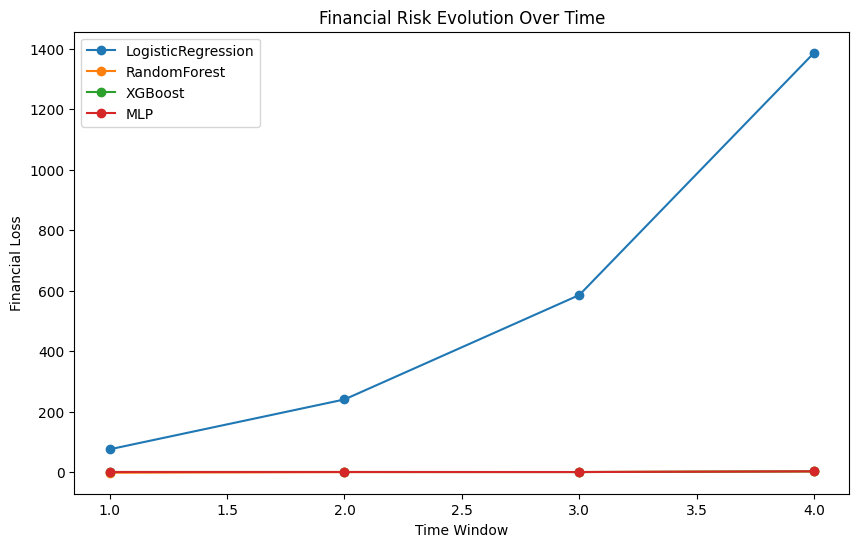

In [73]:
plt.figure(figsize=(10,6))

for model in drift_df["Model"].unique():
    subset = drift_df[drift_df["Model"]==model]
    plt.plot(subset["Window"], subset["Financial_Loss"], marker='o', label=model)

plt.title("Financial Risk Evolution Over Time")
plt.xlabel("Time Window")
plt.ylabel("Financial Loss")
plt.legend()
plt.show()

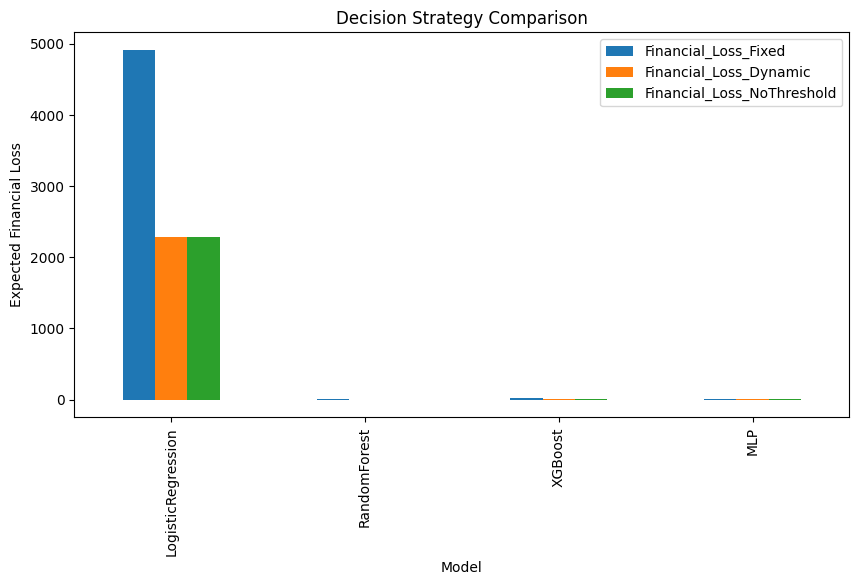

In [74]:
comparison.plot(
    x="Model",
    y=[
        "Financial_Loss_Fixed",
        "Financial_Loss_Dynamic",
        "Financial_Loss_NoThreshold"
    ],
    kind="bar",
    figsize=(10,5)
)

plt.title("Decision Strategy Comparison")
plt.ylabel("Expected Financial Loss")
plt.show()

In [75]:
!pip install river -q
from river.drift import ADWIN

In [76]:
# ADWIN drift detector
drift_detector = ADWIN()

# choose model for adaptive learning
adaptive_model = models["XGBoost"]

adaptive_losses = []
drift_locations = []

# rolling buffer for retraining
buffer_X = []
buffer_y = []

RETRAIN_WINDOW = 5000   # recent samples used for retraining

In [77]:
for i in range(len(X_test)):

    # current transaction
    x_i = X_test.iloc[[i]]
    y_true = y_test.iloc[i]
    amt = amount_test.iloc[i]

    # predict probability
    prob = adaptive_model.predict_proba(x_i)[0,1]

    # threshold-free decision rule
    pred = cost_minimization_decision(
        np.array([prob]),
        np.array([amt]),
        INVESTIGATION_COST
    )[0]

    # financial loss calculation
    if y_true == 1 and pred == 0:
        loss = abs(amt)
    elif y_true == 0 and pred == 1:
        loss = INVESTIGATION_COST
    else:
        loss = 0

    adaptive_losses.append(loss)

    # update drift detector
    drift_detector.update(loss)

    # store recent data
    buffer_X.append(x_i.values[0])
    buffer_y.append(y_true)

    if len(buffer_X) > RETRAIN_WINDOW:
        buffer_X.pop(0)
        buffer_y.pop(0)

    # -----------------------------
    # AUTO RETRAIN TRIGGER
    # -----------------------------
    if drift_detector.drift_detected:

        print(f"⚠ Drift detected at transaction {i} — Retraining model")

        drift_locations.append(i)

        adaptive_model.fit(
            np.array(buffer_X),
            np.array(buffer_y)
        )

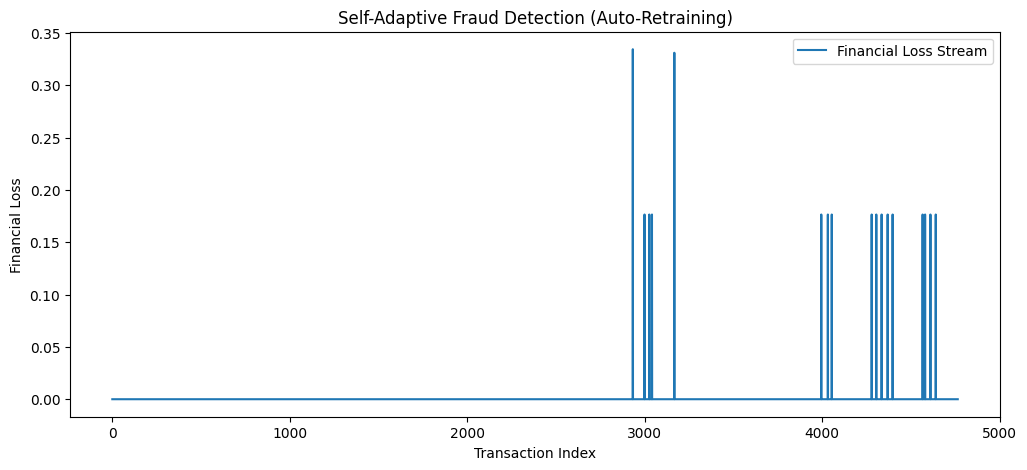

Retraining triggered at: []


In [78]:
plt.figure(figsize=(12,5))
plt.plot(adaptive_losses, label="Financial Loss Stream")

for d in drift_locations:
    plt.axvline(d, color='red', linestyle='--')

plt.title("Self-Adaptive Fraud Detection (Auto-Retraining)")
plt.xlabel("Transaction Index")
plt.ylabel("Financial Loss")
plt.legend()
plt.show()

print("Retraining triggered at:", drift_locations[:10])

In [79]:
from sklearn.linear_model import SGDClassifier

# Online learning decision policy
policy_model = SGDClassifier(
    loss="log_loss",
    learning_rate="optimal",
    random_state=42
)

policy_initialized = False

policy_rewards = []
policy_actions = []

In [80]:
def financial_reward(y_true, action, amount, C_inv=5):

    # action: 1 = block, 0 = allow

    if y_true == 1 and action == 1:
        return abs(amount)       # fraud prevented

    elif y_true == 1 and action == 0:
        return -abs(amount)      # fraud missed

    elif y_true == 0 and action == 1:
        return -C_inv            # investigation cost

    else:
        return 1                 # correct allow (small reward)

In [81]:
adaptive_probs = adaptive_model.predict_proba(X_test)[:,1]

for i in range(len(X_test)):

    prob = adaptive_probs[i]
    amt = amount_test.iloc[i]
    y_true = y_test.iloc[i]

    # -----------------------------
    # NaN SAFETY FIX (IMPORTANT)
    # -----------------------------
    if np.isnan(prob):
        prob = 0.5   # neutral uncertainty

    if np.isnan(amt):
        amt = 0.0

    # state representation
    state = np.array([[prob, abs(amt)]])

    # initialize learner once
    if not policy_initialized:
        policy_model.partial_fit(state, [0], classes=[0,1])
        policy_initialized = True

    # policy decides action
    action = policy_model.predict(state)[0]

    # compute reward
    reward = financial_reward(
        y_true,
        action,
        amt,
        INVESTIGATION_COST
    )

    policy_rewards.append(reward)
    policy_actions.append(action)

    # learning signal
    label = 1 if reward > 0 else 0

    policy_model.partial_fit(state, [label])

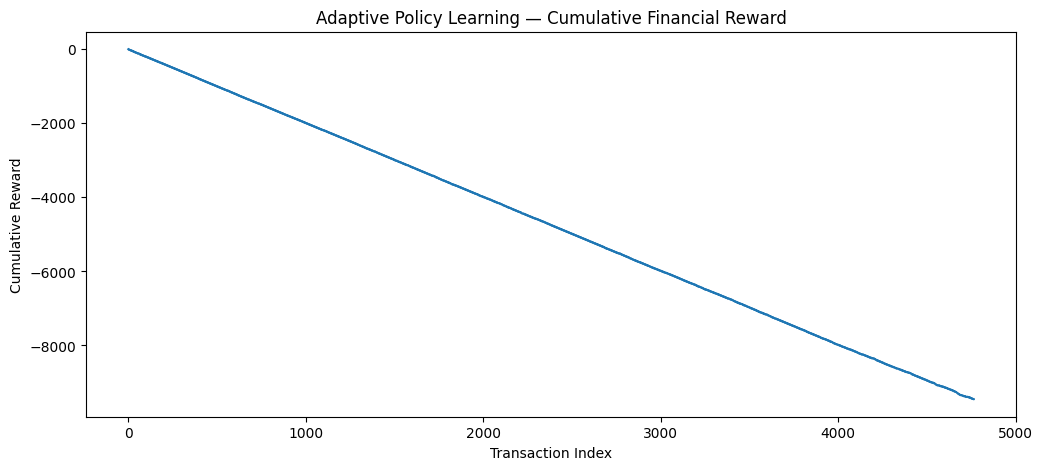

In [82]:
plt.figure(figsize=(12,5))
plt.plot(np.cumsum(policy_rewards))

plt.title("Adaptive Policy Learning — Cumulative Financial Reward")
plt.xlabel("Transaction Index")
plt.ylabel("Cumulative Reward")
plt.show()

In [83]:
policy_preds = np.array(policy_actions)

# ----------------------------------
# STREAM ALIGNMENT (FINAL FIX)
# ----------------------------------
len_preds = len(policy_preds)
len_labels = len(y_test)
len_amounts = len(amount_test)

min_len = min(len_preds, len_labels, len_amounts)

print("Predictions:", len_preds)
print("Labels:", len_labels)
print("Amounts:", len_amounts)
print("Aligned evaluation length:", min_len)

# Align all arrays safely
y_eval = np.array(y_test.iloc[:min_len])
amount_eval = np.array(amount_test.iloc[:min_len])
policy_eval = policy_preds[:min_len]

# Compute financial loss
policy_loss = financial_loss(
    y_eval,
    policy_eval,
    amount_eval,
    INVESTIGATION_COST
)

print("\nFinancial Loss using Adaptive Policy:", policy_loss)

Predictions: 4765
Labels: 4765
Amounts: 4765
Aligned evaluation length: 4765

Financial Loss using Adaptive Policy: 11824.018522281509


In [84]:
# Convert learning signals to numpy arrays
policy_rewards_np = np.array(policy_rewards)
adaptive_losses_np = np.array(adaptive_losses)

print("Total policy decisions:", len(policy_rewards_np))

Total policy decisions: 4765


In [85]:
def moving_average(data, window=500):
    if len(data) < window:
        return data
    return np.convolve(data, np.ones(window)/window, mode='valid')

In [86]:
# cumulative reward (policy improvement)
cumulative_reward = np.cumsum(policy_rewards_np)

# smoothed financial loss trend
smoothed_loss = moving_average(adaptive_losses_np, window=500)

reward_x = np.arange(len(cumulative_reward))
loss_x = np.arange(len(smoothed_loss))

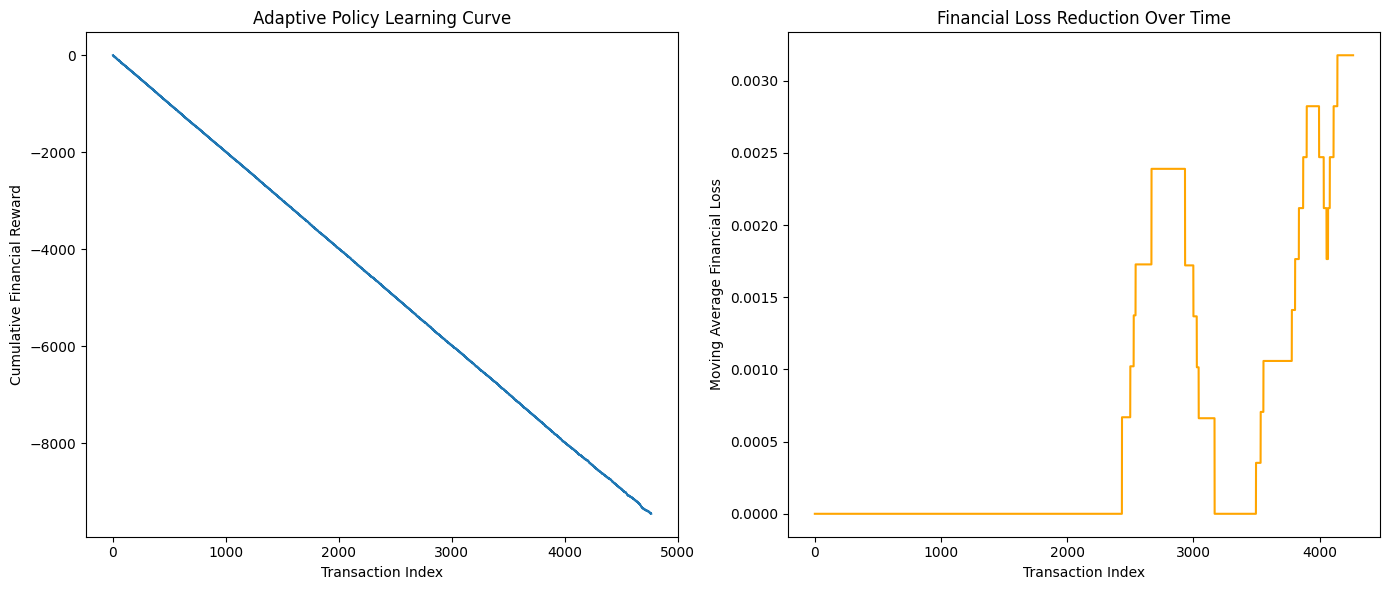

In [87]:
plt.figure(figsize=(14,6))

# -------------------------------
# Policy Improvement
# -------------------------------
plt.subplot(1,2,1)
plt.plot(reward_x, cumulative_reward)
plt.title("Adaptive Policy Learning Curve")
plt.xlabel("Transaction Index")
plt.ylabel("Cumulative Financial Reward")

# -------------------------------
# Financial Risk Reduction
# -------------------------------
plt.subplot(1,2,2)
plt.plot(loss_x, smoothed_loss, color="orange")
plt.title("Financial Loss Reduction Over Time")
plt.xlabel("Transaction Index")
plt.ylabel("Moving Average Financial Loss")

plt.tight_layout()
plt.show()

In [88]:
split = len(policy_rewards_np)//2

early_reward = policy_rewards_np[:split].sum()
late_reward  = policy_rewards_np[split:].sum()

improvement = ((late_reward - early_reward) /
               (abs(early_reward)+1e-9)) * 100

print("Early Stage Reward :", early_reward)
print("Late Stage Reward  :", late_reward)
print("Learning Improvement (%):", improvement)

Early Stage Reward : -4748.691102497089
Late Stage Reward  : -4702.841824531577
Learning Improvement (%): 0.9655140116692839
